In [1]:
import pandas as pd

train_df = pd.read_csv('/content/Train (1).csv')

print(train_df.head())
print(f"\nTotal Rows: {len(train_df)}")

   Width  Height  Roi.X1  Roi.Y1  Roi.X2  Roi.Y2  ClassId  \
0     27      26       5       5      22      20       20   
1     28      27       5       6      23      22       20   
2     29      26       6       5      24      21       20   
3     28      27       5       6      23      22       20   
4     28      26       5       5      23      21       20   

                             Path  
0  Train/20/00020_00000_00000.png  
1  Train/20/00020_00000_00001.png  
2  Train/20/00020_00000_00002.png  
3  Train/20/00020_00000_00003.png  
4  Train/20/00020_00000_00004.png  

Total Rows: 39209


In [2]:
import os
import matplotlib.pyplot as plt
from PIL import Image

img_path = '/content/' + train_df.iloc[0]['Path']
print(f"Checking for image at: {img_path}")

if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title("Image Found!")
    plt.axis('off')
    plt.show()
else:
    print("ERROR: Image folder not found!")
    print("You need to upload the full dataset ZIP file (archive.zip) which contains the images, not just the CSV files.")

Checking for image at: /content/Train/20/00020_00000_00000.png
ERROR: Image folder not found!
You need to upload the full dataset ZIP file (archive.zip) which contains the images, not just the CSV files.


In [9]:
import zipfile
import os

with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Extracted successfully!")
print(os.listdir('/content/'))

Extracted successfully!
['.config', 'archive.zip', 'Test', 'test', 'Train', 'Meta', 'meta', 'Train.csv', '.ipynb_checkpoints', 'train', 'Test.csv', 'Meta.csv', 'sample_data']


Checking for image at: /content/Train/20/00020_00000_00000.png


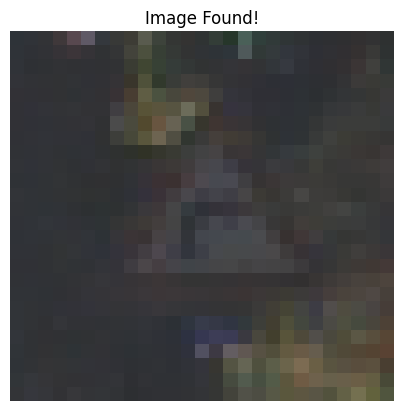

In [10]:
import os
import matplotlib.pyplot as plt
from PIL import Image

img_path = '/content/' + train_df.iloc[0]['Path']
print(f"Checking for image at: {img_path}")

if os.path.exists(img_path):
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title("Image Found!")
    plt.axis('off')
    plt.show()
else:
    print("ERROR: Image not found!")

In [13]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_df['ClassId'] = train_df['ClassId'].astype(str)

IMG_HEIGHT = 30
IMG_WIDTH = 30
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/content/',
    x_col='Path',
    y_col='ClassId',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory='/content/',
    x_col='Path',
    y_col='ClassId',
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

print("Data preprocessing completed successfully!")

Found 31368 validated image filenames belonging to 43 classes.
Found 7841 validated image filenames belonging to 43 classes.
Data preprocessing completed successfully!


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(30, 30, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(43, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 319,979 (1.22 MB)

 Trainable params: 319,979 (1.22 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 10

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)

print("Model Training completed successfully!")

Epoch 1/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 69s 137ms/step - accuracy: 0.5255 - loss: 1.7257 - val_accuracy: 0.0747 - val_loss: 13.3285
Epoch 2/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 52s 106ms/step - accuracy: 0.8316 - loss: 0.5422 - val_accuracy: 0.1155 - val_loss: 19.7385
Epoch 3/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 58s 117ms/step - accuracy: 0.8944 - loss: 0.3353 - val_accuracy: 0.1436 - val_loss: 23.5029
Epoch 4/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 56s 114ms/step - accuracy: 0.9251 - loss: 0.2452 - val_accuracy: 0.1681 - val_loss: 24.5957
Epoch 5/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 51s 104ms/step - accuracy: 0.9400 - loss: 0.1947 - val_accuracy: 0.1505 - val_loss: 28.2119
Epoch 6/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 87s 114ms/step - accuracy: 0.9478 - loss: 0.1636 - val_accuracy: 0.1594 - val_loss: 28.4075
Epoch 7/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.9584 - loss: 0.1324 - val_accuracy: 0.1697 - val_loss: 30.0274
Epoch 8/10
491/491 ━━━━━━━━━━━━━━━━━━━━ 52s 105ms/step - accuracy: 0.9615 - 

In [16]:
import pandas as pd
import numpy as np

test_df = pd.read_csv('/content/Test.csv')
test_df['ClassId'] = test_df['ClassId'].astype(str)

test_generator = train_datagen.flow_from_dataframe(
    dataframe=test_df,
    directory='/content/',
    x_col='Path',
    y_col='ClassId',
    target_size=(30, 30),
    batch_size=64,
    class_mode='categorical',
    shuffle=False
)

evaluation = model.evaluate(test_generator)
print(f"Test Accuracy: {evaluation[1]*100:.2f}%")

Found 12630 validated image filenames belonging to 43 classes.
198/198 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.7937 - loss: 8.1080
Test Accuracy: 79.37%


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image

img_path = '/content/' + test_df.iloc[0]['Path']
img = image.load_img(img_path, target_size=(30, 30))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)

print(f"Predicted Traffic Sign Class ID: {predicted_class}")
print(f"Actual Class ID: {test_df.iloc[0]['ClassId']}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
Predicted Traffic Sign Class ID: 8
Actual Class ID: 16


In [18]:
model.save('traffic_sign_model.h5')
print("Model saved successfully!")

Model saved successfully!


In [19]:
import os
import shutil

os.makedirs('/content/sample_test_images', exist_ok=True)

for i in range(10):
    img_path = test_df.iloc[i]['Path']
    src = os.path.join('/content/', img_path)
    if os.path.exists(src):
        shutil.copy(src, '/content/sample_test_images/')

shutil.make_archive('/content/sample_test_images', 'zip', '/content/sample_test_images')
print("Sample test images zipped successfully!")

Sample test images zipped successfully!
